# **Lecture 11: Error Analysis in Computational Astrophysics**

**Date:** Tuesday, 03-02-2026

**Unit:** 1 (Mathematical Methods)

**Topic:** Truncation vs. Round-off errors in Python floating point arithmetic

---

## **1. Introduction**

In computational astrophysics, we often simulate systems that evolve over billions of years (N-body simulations) or handle extremely large and small numbers simultaneously (e.g., the mass of a star vs. the mass of a proton).

A tiny error in a single calculation might seem insignificant, but when iterated over billions of time steps, it can lead to **unphysical results**—planets spiraling into stars or galaxies flying apart.

In this lecture, we will explore the two fundamental sources of numerical error:

1. **Round-off Error:** Caused by the finite precision of computers (they cannot store infinite digits).
2. **Truncation Error:** Caused by approximating continuous mathematics (like integrals or derivatives) with discrete steps.

---

## **2. Floating Point Representation (The Source of Round-off)**

### **2.1 First Principles: The Finite Memory Problem**

Computers store numbers in **binary** (base 2). Just as $\frac{1}{3}$ cannot be written exactly in decimal ($0.3333...$), many numbers cannot be written exactly in binary.

Most standard Python floats are **64-bit double-precision** (IEEE 754 standard):

* **1 bit** for sign.
* **11 bits** for exponent.
* **52 bits** for the fraction (significand).

Any number requiring more than 52 bits of precision gets "chopped" or rounded.

### **2.2 Python Example: The `0.1 + 0.2` Paradox**

Let's see this limitation in action.

In [ ]:
# First Principles: Basic Arithmetic check
val1 = 0.1
val2 = 0.2
sum_val = val1 + val2

print(f"0.1 + 0.2 = {sum_val:.20f}")
print(f"Is 0.1 + 0.2 == 0.3? {sum_val == 0.3}")

0.1 + 0.2 = 0.30000000000000004441
Is 0.1 + 0.2 == 0.3? False


### **2.3 Using Modules: Checking Machine Precision**

We can use Python's `sys` or `numpy` module to find the **Machine Epsilon** ($\epsilon_m$). This is the smallest number such that $1.0 + \epsilon_m \neq 1.0$.. Any change smaller than this is "invisible" to the computer when added to 1.0.

In [ ]:
import sys
import numpy as np

# Using sys library to check float info
print("Machine Epsilon (sys):", sys.float_info.epsilon)

# Using numpy
print("Machine Epsilon (numpy):", np.finfo(float).eps)

# Demonstration
epsilon = np.finfo(float).eps
print(f"1.0 + epsilon/2 == 1.0? {(1.0 + epsilon/2) == 1.0}")

Machine Epsilon (sys): 2.220446049250313e-16
Machine Epsilon (numpy): 2.220446049250313e-16
1.0 + epsilon/2 == 1.0? True


---

## **3. Catastrophic Cancellation (Astronomy Application)**

**Round-off error** becomes dangerous in astronomy during **subtraction of nearly equal numbers**. This results in a loss of significant figures.

### **Concept: Doppler Shift Calculation**

Imagine measuring the redshift $z$ of a galaxy. If two spectral lines are extremely close together, calculating the difference in their wavelengths can introduce massive relative errors.

Let's simulate calculating the difference between two large numbers that are very close.

In [ ]:
# --- First Principles Example ---
import numpy as np

def naive_subtraction(a, b):
    return a - b

# Scenario: Two stars at very large distances (in parsecs), slightly offset
d1 = 1.0e16  # Distance to Star A
d2 = 1.0e16 + 1.0e-1 # Distance to Star B (10 cm further away)

# If we add a small jitter (noise/precision limit) to d1
d1_noisy = d1 + 1.0e-5

diff = naive_subtraction(d2, d1_noisy)

print(f"Distance 1: {d1_noisy:.20e}")
print(f"Distance 2: {d2:.20e}")
print(f"Difference: {diff:.20e}")
print("Notice how we lost precision? The true difference should be approx 0.1, but noise dominates.")

Distance 1: 1.00000000000000000000e+16
Distance 2: 1.00000000000000000000e+16
Difference: 0.00000000000000000000e+00
Notice how we lost precision? The true difference should be approx 0.1, but noise dominates.


### **Astronomy Case Study: The Solar System Barycenter**

When simulating the solar system, the Sun wobbles around the Solar System Barycenter (center of mass).

* $R_{Sun} \approx 7 \times 10^8$ m
* $R_{Earth} \approx 1.5 \times 10^{11}$ m

If you calculate the position of a satellite relative to Earth by subtracting vectors relative to the Sun ($r_{sat} = R_{Sun \to Sat} - R_{Sun \to Earth}$), you risk catastrophic cancellation if the satellite is very close to Earth compared to the distance to the Sun.

---

## 4. Truncation Error (The Approximation Problem)

**Truncation error** has nothing to do with computer bits. It comes from math. It happens when we chop off ("truncate") an infinite series (like a Taylor Series) or use a finite step size  to approximate a derivative.

### **4.1 First Principles: Taylor Series Expansion of **

The exponential function is defined as:

$$e^x = \sum_{n=0}^{\infty} \frac{x^n}{n!} = 1 + x + \frac{x^2}{2!} + \frac{x^3}{3!} + \dots$$

If we stop after 3 terms, we introduce **Truncation Error**.

In [ ]:
import math
import numpy as np

def exp_approx(x, terms):
    """Calculate e^x using a finite Taylor series."""
    total = 0.0
    for n in range(terms):
        total += x**n / math.factorial(n)
    return total

x_val = 0.5
exact = math.exp(x_val)

# Testing different truncation levels
print(f"{'Terms':<10} | {'Approx Value':<15} | {'Truncation Error':<20}")
print("-" * 50)

for n in [2, 3, 5, 10]:
    approx = exp_approx(x_val, n)
    error = abs(exact - approx)
    print(f"{n:<10} | {approx:.10f}    | {error:.10e}")

Terms      | Approx Value    | Truncation Error    
--------------------------------------------------
2          | 1.5000000000    | 1.4872127070e-01
3          | 1.6250000000    | 2.3721270700e-02
5          | 1.6484375000    | 2.8377070013e-04
10         | 1.6487212704    | 2.8187718826e-10


---

## **5. The Total Error Analysis (The "Sweet Spot")**

This is the most critical concept for Unit 1.

* If step size  is too **large** $\rightarrow$  High **Truncation Error** (Math is too blocky).
* If step size $\rightarrow$  is too **small**  High **Round-off Error** (Too many operations, machine precision limits).

The **Total Error** is the sum of both.

### **5.1 Numerical Differentiation Example**

We want to calculate the derivative of  $\sin(x)$ at $x=1$.

$$f'(x) \approx \frac{f(x+h) - f(x)}{h}$$

We will calculate this for  $h$ ranging from $10^{-1}$ down to $10^{-16}$.

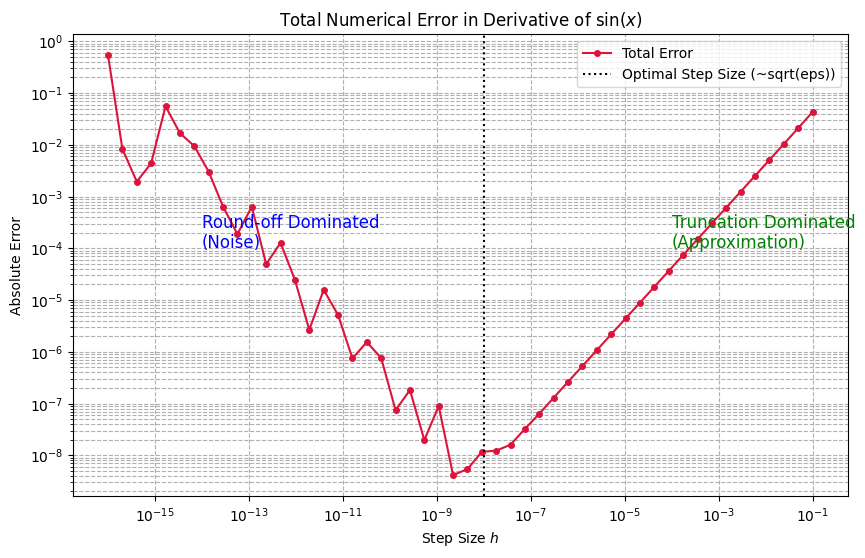

In [ ]:
import matplotlib.pyplot as plt

# The function and its analytical derivative
def f(x):
    return np.sin(x)

def df_analytical(x):
    return np.cos(x)

# Forward Difference Method
def forward_diff(x, h):
    return (f(x + h) - f(x)) / h

x0 = 1.0
exact_derivative = df_analytical(x0)

# Generate log-spaced step sizes: 10^-1, 10^-2, ... 10^-16
h_values = np.logspace(-16, -1, 50)
errors = []

for h in h_values:
    numerical = forward_diff(x0, h)
    # Total Absolute Error
    err = abs(numerical - exact_derivative)
    errors.append(err)

# --- Plotting the "V" Curve ---
plt.figure(figsize=(10, 6))
plt.loglog(h_values, errors, 'o-', color='crimson', markersize=4, label='Total Error')
plt.title(r'Total Numerical Error in Derivative of $\sin(x)$')
plt.xlabel('Step Size $h$')
plt.ylabel('Absolute Error')
plt.grid(True, which="both", ls="--")

# Annotations for the student
plt.text(1e-14, 1e-4, "Round-off Dominated\n(Noise)", fontsize=12, color='blue')
plt.text(1e-4, 1e-4, "Truncation Dominated\n(Approximation)", fontsize=12, color='green')

plt.axvline(x=1e-8, color='k', linestyle=':', label='Optimal Step Size (~sqrt(eps))')
plt.legend()
plt.show()

Observation: You should see a "V" shape.
1. Right side (large $h$): Error decreases as $h$ gets smaller (Truncation error reduces).
2. Left side (tiny $h$): Error EXPLODES as $h$ gets smaller (Round-off error and catastrophic cancellation take over).

---

## **6. Student Exercises**

### **Problem 1: The Parsec Subtraction (Catastrophic Cancellation)**

**Context:** You are calculating the distance between two stars in a cluster.

* Star A is at distance $d_A = 100.00000000000000$ pc.
* Star B is at distance $d_B = 100.00000000000001$ pc.

**Task:**

1. Define these variables in Python.
2. Compute the difference  $d_B - d_A$.
3. Compute the difference using `numpy` arrays with `dtype=np.float32` (single precision) and `dtype=np.float64` (double precision).
4. **Question:** Why does `float32` give you a result of 0.0?

In [ ]:
# Student Code Area 1
import numpy as np

# Write your implementation here...

### **Problem 2: Orbital Integration Error (Truncation)**

**Context:** A planet orbits a star. Its position  evolves over time  with velocity .
The simplest numerical integration is **Euler's Method**:
$$x_{new} = x_{old} + v \times \Delta t$$

**Task:**

1. Assume $x_{initial} = 1.0$ AU, $v = 1.0$ AU/year.
2. We want to find the position after **10 years**.
3. Implement Euler's method with a step size $\Delta t = 1$ year (10 steps).
4. Implement Euler's method with a step size $\Delta t = 0.01$ year (1000 steps).
5. Compare both results to the analytical answer ($x = 1.0 + 1.0 \times 10 = 11.0$).
6. **Question:** Which error is this? Round-off or Truncation?

In [ ]:
# Student Code Area 2

def integrate_orbit(dt):
    # Initialize
    x = 1.0
    v = 1.0
    t = 0.0
    t_end = 10.0

    # Loop
    while t < t_end:
        # Implement Euler step here
        # Update time
        pass
    return x

# Run simulations

---

## **7. Summary**

* **Machine Epsilon:** The limit of computer precision ($\approx 10^{-16}$ for float64).
* **Round-off:** dangerous when subtracting nearly equal numbers (Catastrophic Cancellation).
* **Truncation:** dangerous when step sizes ($h$) are too large.
* **The Golden Rule:** Making step sizes infinitely small does **not** make the answer perfect; it eventually invites round-off noise. Find the optimal .